<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/toxic_text_classification_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [5]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [8]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [9]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

In [10]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [11]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [12]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [13]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [14]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [15]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [16]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id                                       comment_text  toxic  \
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...    NaN   
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...    NaN   
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...    NaN   
3  00017563c3f7919a  :If you have a look back at the source, the in...    NaN   
4  00017695ad8997eb          I don't anonymously edit articles at all.    NaN   

   severe_toxic  obscene  threat  insult  identity_hate  
0           NaN      NaN     NaN     NaN            NaN  
1           NaN      NaN     NaN     NaN            NaN  
2           NaN      NaN     NaN     NaN            NaN  
3           NaN      NaN     NaN     NaN            NaN  
4           NaN      NaN     NaN     NaN            NaN  


**Binary 'any_toxic' column **




In [17]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [18]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [19]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

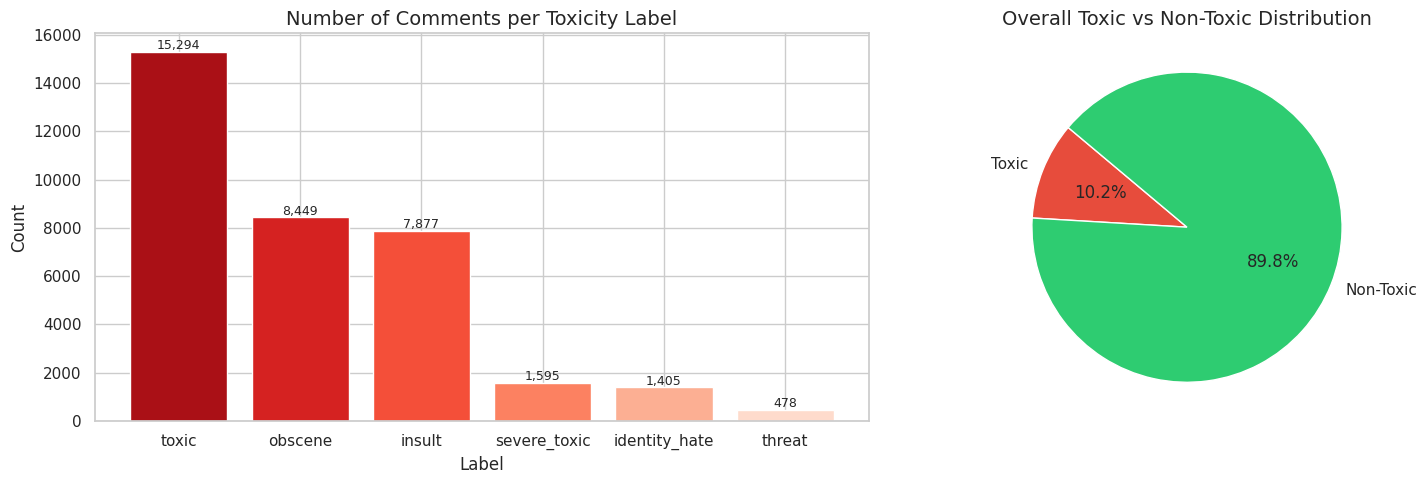

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [21]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

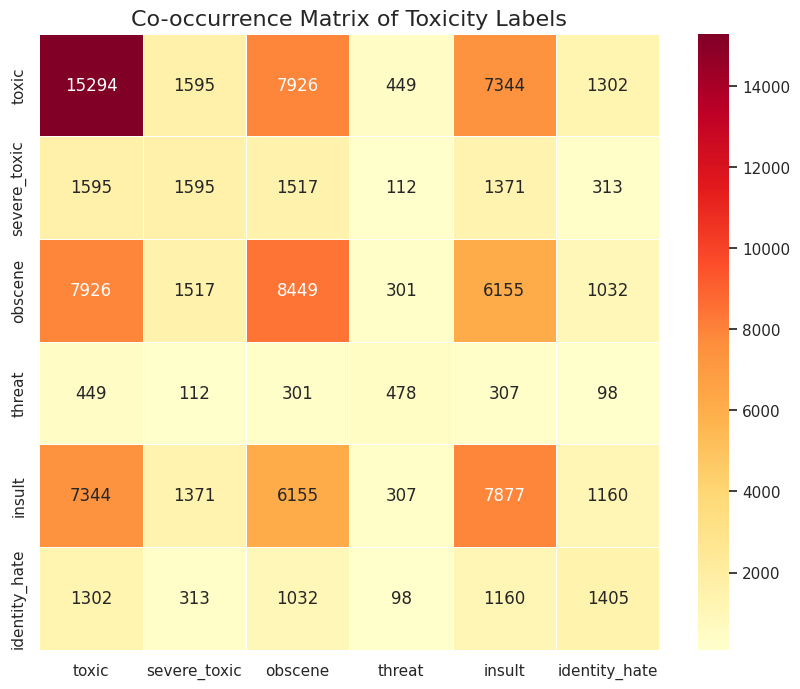

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

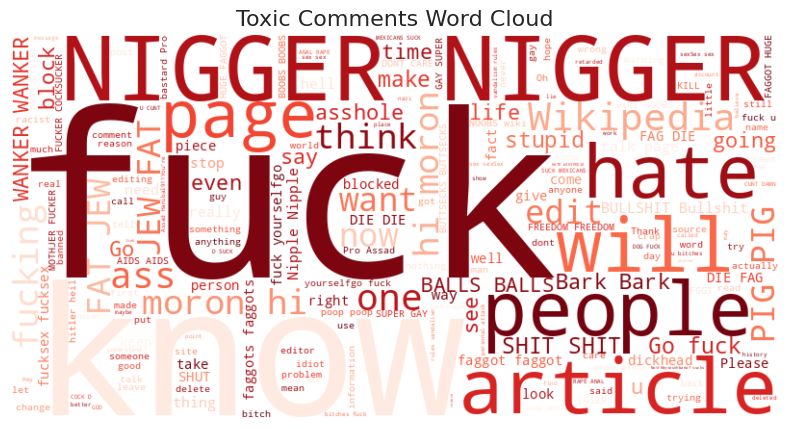

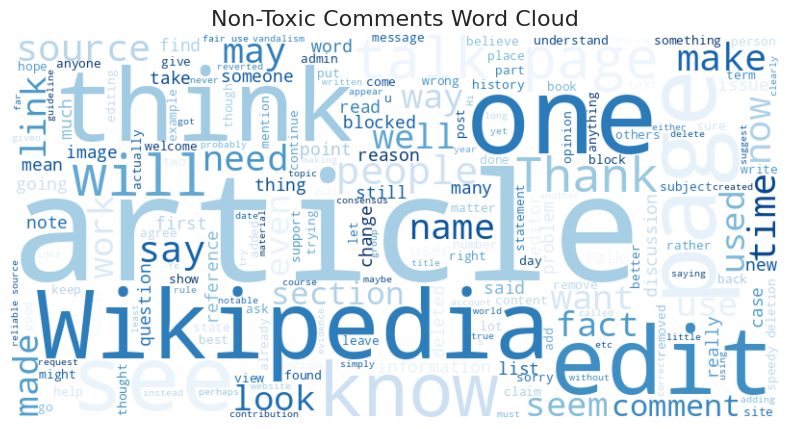

In [23]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

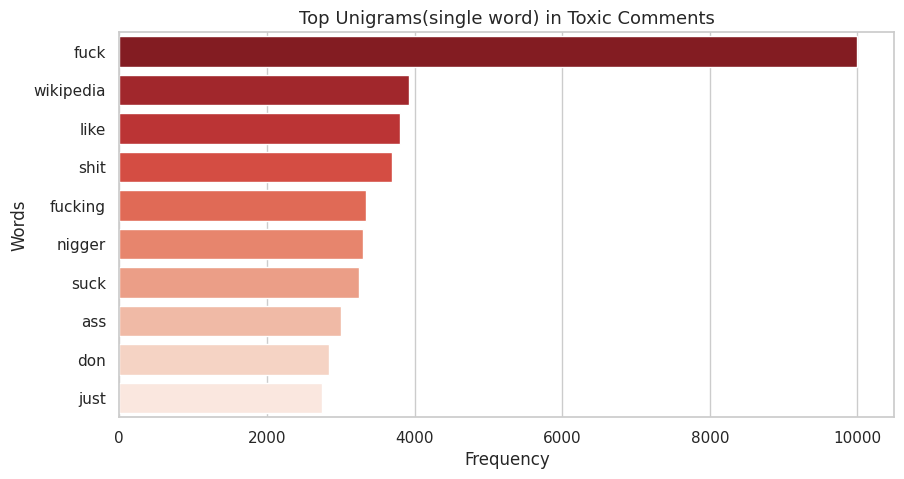

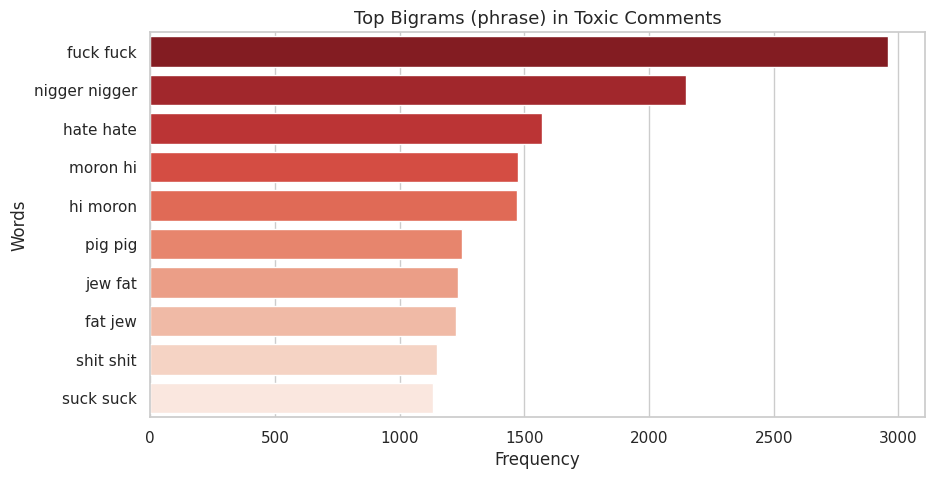

In [24]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [25]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
45096,"""No mention of the Belcher family. Google """"Be...",0
84308,That's what the power you get when you be an a...,0
120324,"""Also, please tell me why calling Taliaferro a...",0
45158,Note that I use endless IP's.,0
158492,Similarly did he die at Kings Cross or Torquay?,0
1927,it would be good to know who is funding this,0


**Basic Preprocessing**



1.   Lower case




In [26]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [27]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [28]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [29]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [30]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [31]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [32]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.0 MB/s eta 0:00:00


1. Emoji to text

In [33]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [34]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [35]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [36]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [37]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [38]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [41]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [ ]:

# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

Stopwords

In [45]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [46]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [47]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [ ]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [55]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [49]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
82678,For you to even refer to resolution shows your a moron. It's more than adequate for the size of the \nimage in the article. Anything higher would clearly allow unauthorized reproduction at a higher quality. Just to make sure I'm not being ambiguous in anyway.....GO FUCK YOURSELF
78249,[Sources were pointed out by Ghatus himself.]
110376,"""\n\nCopyright problem: Badaga Hattis\nHello, and welcome to Wikipedia! We welcome and appreciate your contributions, such as Badaga Hattis, but we regretfully cannot accept copyrighted text or images borrowed from either web sites or printed material. This article appears to contain material copied from http://badaga.wordpress.com/badaga-villages-nakku-betta-hattis/, and therefore to constitute a violation of Wikipedia's copyright policies. The copyrighted text has been or will soon be deleted. While we appreciate contributions, we must require all contributors to understand and comply with our copyright policy. Wikipedia takes copyright violations very seriously, and persistent violators are liable to be blocked from editing. \n\nIf you believe that the article is not a copyright violation, or if you have permission from the copyright holder to release the content freely under license allowed by Wikipedia, then you should do one of the following:\n\nIf you have permission from the author to release the text under the Creative Commons Attribution-ShareAlike License (CC-BY-SA), leave a message explaining the details at Talk:Badaga Hattis and send an email with confirmation of permission to """"permissions-en (at) wikimedia (dot) org"""". Make sure you quote the exact page name, Badaga Hattis, in your email. See Wikipedia:Requesting copyright permission for instructions.\nIf a note on the original website states that re-use is permitted """"under the Creative Commons Attribution-ShareAlike License (CC-BY-SA), version 3.0, or that the material is released into the public domain leave a note at Talk:Badaga Hattis with a link to where we can find that note. \nIf you own the copyright to the material: send an e-mail from an address associated with the original publication to permissions-en(at)wikimedia(dot)org or a postal message to the Wikimedia Foundation permitting re-use under the Creative Commons Attribution-ShareAlike License and GNU Free Documentation License, and note that you have done so on Talk:Badaga Hattis. See Wikipedia:Donating copyrighted materials for instructions.\nIt may also be necessary for the text be modified to have an encyclopedic tone and to follow Wikipedia article layout. For more information on Wikipedia's policies, see Wikipedia's policies and guidelines. \n\nIf you would like to begin working on a new version of the article you may do so at [ this temporary page]. Leave a note at Talk:Badaga Hattis saying you have done so and an administrator will move the new article into place once the issue is resolved. \nThank you, and please feel welcome to continue contributing to Wikipedia. Happy editing! """
108715,"I fly home on the 25th, but not until nighttime. What time is the event?"
38750,"""\n\n Excellent work! \nI have been away from Wikipedia for years, and largely due to users like the despicable, self-deluded Gavin Collins. To return here after so much time and find that he has been removed from the site is an utter joy, on several levels. Justice has finally been served, proving that the system here actually works, albeit slowly. However, I can't help but feel sick about the time, energy, and effort the Wikipedia community has expended (i.e., wasted) in dealing with this Gavin Collins, a terrifically disruptive and possibly mentally disturbed individual. It is incredible to me that one user has caused such extensive damage and unending headache, heartache, and loss of resources. Yes, instead of spending hundreds of hours dealing with Gavin Collins' nonsensical, myopic, obtuse, elliptical, deconstructive, and dense argumentation, we could all have been m

Applying Basic Preprocessing

In [50]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
34968,wolverinophobia wolverinophobia is said to describe the fear of the marvel company character named wolverine the fear does not allow people who suffer it to go anywhere near an image or representation that assimilates the character serious cases such as the manuels maniatic case even take defensive actions towards an image or poster causing the spread of fear and panic on the people around him it may also cause the destruction of hes or hers house
129467,gasiorowski coauthor malcolm byrne edits the nsarchives iran documents this one dated is directly relevant to this wikipedia article this is byrnes comments about the linked state department report to eisenhower which you have to click to read as byrne does not summarize it memorandum for the president discussing behavior of the shah gen zahedi and winston churchill immediately after the coup memorandum from the department of state top secret circa august prior to the hostagetaking episode the most contentious issue in usiran relations was the coup against iranian prime minister mohammad mossadeq which the cia and british intelligence helped to instigate numerous questions remain about the coup itself its impact and the circumstances which brought it about to what extent was mossadeq leading his country down the path toward communist subversion could the coup have succeeded without substantial iranian public dissatisfaction with mossadeqs policies did key iranian political and religious figures wittingly or not receive cia payments in return for stirring up the population what effects did the coup have on the future development of internal iranian politics including possibly radicalizing antishah and antiamerican opposition elements with consequences that would not be foreseen until the revolution itself the search for answers will have to wait at least until more of the documentary record is available in both iran and the united states unfortunately a portion of the record on the american side will never be recovered because cia operatives according to former director of central intelligence james woolsey destroyed them in the s the surviving files remain locked away from public view on the grounds that their declassification even years later would damage the national security because of the obvious public interest value and historical significance of these materials the national security archive in may filed suit against the cia to demand their release the suit is still pending
5532,like the other poster said if you can cite media matters for orielly then you can cite the new york post for olbermann
125526,tony i removed him because of two reasons his name was out of alpha order on the list f surname in a surnames didnt see substantial material that will validate his entry on the list do you have any links that i can look at to come to a solid conclusion many thanks
4104,how much of this pages content should be removed from the spaceway page where it originated with the addition of spaceway it was best to separate the material but should i go back and remove it as well


Comparison Of Raw and Basic Clean by Basic Preprocessing

In [51]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
5886,"FUCK YOU NATLIE YOU DUMBASS CUNTBAG!\nI HAVE A DYNAMIC IP\nU CANNOT BAN ME\nTOUGH SHIT AINT IT CUNT?\n\nso go suck some random ass fuckers cock, before i vandalize your entire site..\nB-I-O-T-C-H!\n\nDONT MAKE ME COME FIND YOUR ASS IN OHIO, I READ YOUR WIKI ENTRY!\nKNOCK KNOCK*\nYOUR DUMB PUTTING THAT MUCH PERSONAL INFO OUT THERE AND CALLING OUT TROLLS WITH\nDYNAMIC IP RANGES YOU DUMB BITCH!",fuck you natlie you dumbass cuntbag i have a dynamic ip u cannot ban me tough shit aint it cunt so go suck some random ass fuckers cock before i vandalize your entire site biotch dont make me come find your ass in ohio i read your wiki entry knock knock your dumb putting that much personal info out there and calling out trolls with dynamic ip ranges you dumb bitch
140780,"It never happens at the Veterans' Administration, for example.",it never happens at the veterans administration for example
138676,Extremely strongly disaggree. It is called other appeerences for a reason.,extremely strongly disaggree it is called other appeerences for a reason
95238,"""\n\nRe: South of Heaven\nI certainly remember you - I have a good knack for remembering names on Wikipedia. As concerns you leaving feedback being """"not so good news"""", that's incorrect. If you hadn't left feedback, that would've been not so good news. Feedback is great since it tightens an article, and I want to thank you for leaving some. Thanks for deeming the article to be GA. If there's an article you want me to look at in order to leave constructive feedback for, feel free to message me. """,re south of heaven i certainly remember you i have a good knack for remembering names on wikipedia as concerns you leaving feedback being not so good news thats incorrect if you hadnt left feedback that wouldve been not so good news feedback is great since it tightens an article and i want to thank you for leaving some thanks for deeming the article to be ga if theres an article you want me to look at in order to leave constructive feedback for feel free to message me
84391,"2013 (UTC)\n\n890 knots at low-level, is what I've read - 1024 mph. That's about Mach 1.3 23:12, 4 December",utc knots at lowlevel is what ive read mph thats about mach december


Applying Advanced Preprocessing

In [57]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [58]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
119105,geez forgetful weve already discussed marx anarchist ie wanted use state mold socialist man ergo statist opposite anarchist know guy say get old teeth fall hell quit eating meat would call vegetarian
131631,carioca rfa thanks support request adminship final outcome administrator comment concern action administrator please let know thank
125326,birthday worry enjoy ur daytalke
111256,pseudoscience category im assuming article pseudoscience category association creationism however modern scientificallyaccepted variant catastrophism nothing creationism theyre even mentioned article think connection pseudoscience need clarified article made general less creationismspecific category tag removed entirely
83590,phrase exists would provided search engine even mentioned page available whole


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [59]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
80988,"""\n\nI have struck out my comment on the WP:RfC page, as you are quite correct in saying that I have no evidence for my """"suspicion"""", although I don't agree with your comment that you had """"already explained that you have been browsing WP for some time"""" - I can't see where you explained this previously. (talk) """,struck comment wprfc page quite correct saying evidence suspicion although agree comment already explained browsing wp time see explained previously talk
141463,please do not reinsert,please reinsert
44537,"""\n\nwell its not """"Vanderlism"""" as you state it. You still should allow the other part of my edit that you keep reverting because you hate the genre so much. 75.139.103.133 """,well vanderlism state still allow part edit keep reverting hate genre much
10601,"""\nFor the record, here is the news blurb that made en.wiki main page news: """"Amid an outbreak of tornadoes and derechos in central and eastern North America, a tornado hits a Boy Scout camp in Iowa, killing four.""""... — • Talk • """,record news blurb made enwiki main page news amid outbreak tornado derechos central eastern north america tornado hit boy scout camp iowa killing four talk
149256,"cajuns, acadians\nCajuns, acadians, louisianans, they're so many different names for different americans of french descent because their culture is so rich and somewhat so different but so close at the same time. I'm an acadian but more importantly I'm a french american so I really don't see why there should be a difference. \n\nIf you say there should be two different list, it doesn't make sense. The people on the french-american list should be in one of wiki-invented list of cajuns or acadians. I understand there are some more recent french-americans who are only 1 or 2 generations-old americans but this distinction isn't made for italian-americans, german-americans. I'm surprised to see Albert Einstein a fairly recent immigrant in American history next to Katherine Heigl, a 10 to 12 generations american. \\\n\nThis is all race-based, biased because french-bashing don't stop at the bush government level.",cajun acadian cajun acadian louisianan theyre many different name different american french descent culture rich somewhat different close time im acadian importantly im french american really see difference say two different list doesnt make sense people frenchamerican list one wikiinvented list cajun acadian understand recent frenchamericans generationsold american distinction isnt made italianamericans germanamericans im surprised see albert einstein fairly recent immigrant american history next katherine heigl generation american racebased biased frenchbashing stop bush government level


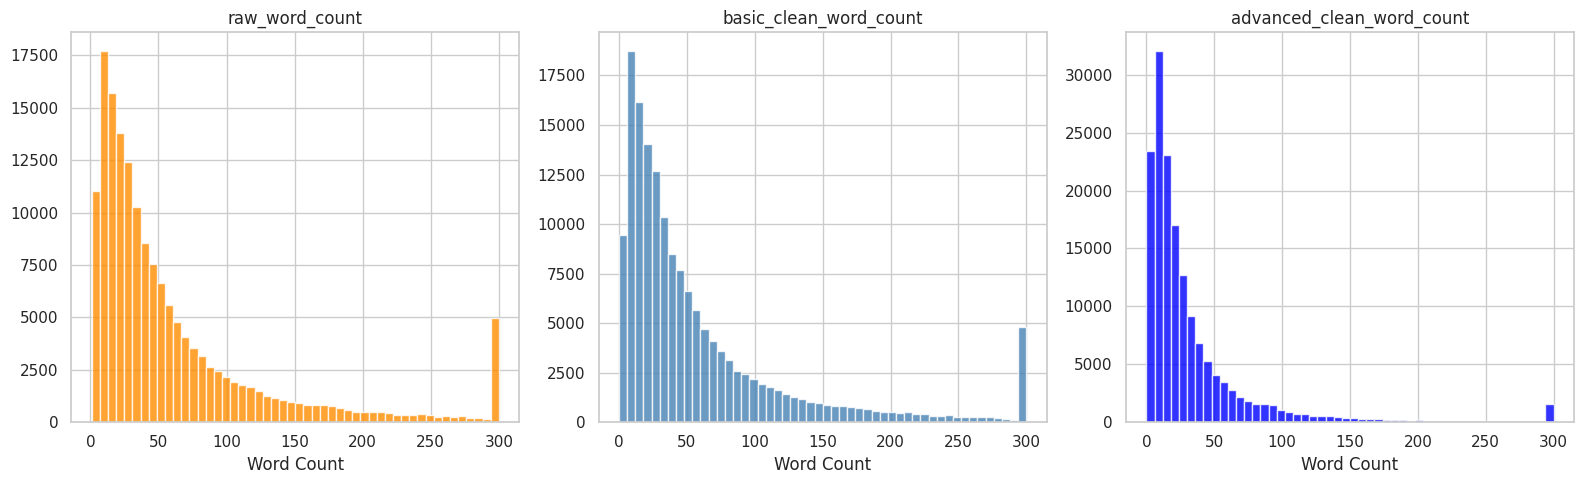

In [60]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [61]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [62]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [63]:
for i in range(5):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [65]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [66]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [67]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [68]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [69]:
Vocab_size =30000
max_len= 200

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts) # Corrected method name to texts_to_sequences
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [70]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 200)
LSTM shape val (15957, 200)
LSTM shape test (15958, 200)


3. BERT Tokenizer (for BERT) \
raw dataset

In [72]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [73]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Evaluation toolkit
for comparing easily

In [96]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [100]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [102]:
def plot_confusion(model_name,y_true, y_pred, labels, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), labels):
       cm = confusion_matrix(y_true[:, labels.index(col)],
                              y_pred[:, labels.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [93]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

In [94]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Train time: 35.0s


Evaluate the model for raw data

In [101]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9207
  precision: 0.8385
  recall   : 0.3947
  f1 Macro : 0.5112
  train time: 35.0s


{'accuracy': 0.9207,
 'precision': 0.8385,
 'recall': 0.3947,
 'f1 (macro)': 0.5112,
 'train time (s)': 35.0,
 'infer time (s)': 0.1}

Confusion plot for the model for raw data

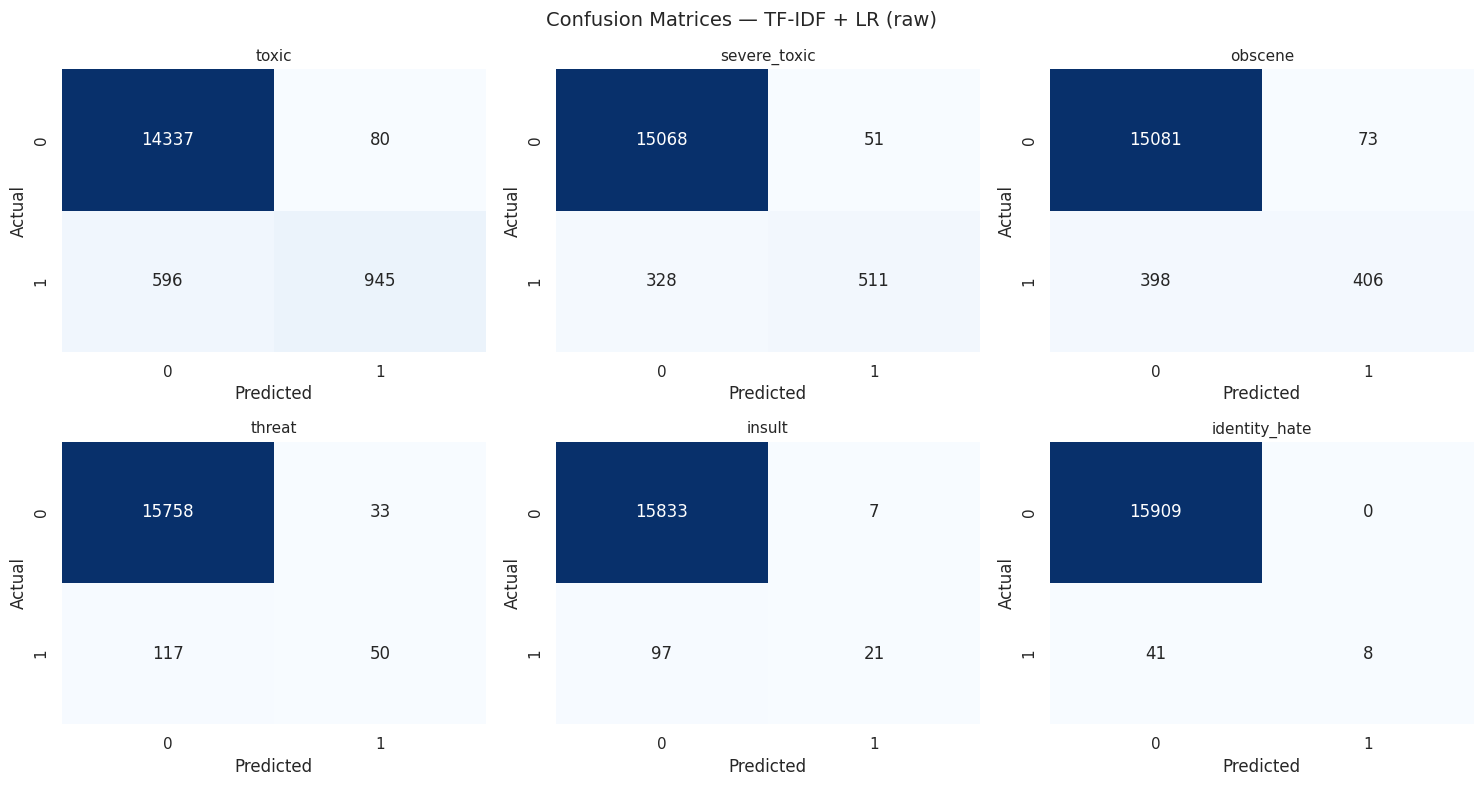

In [103]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

In [104]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 22.6s


In [105]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9180
  precision: 0.7550
  recall   : 0.3838
  f1 Macro : 0.4838
  train time: 22.6s


{'accuracy': 0.918,
 'precision': 0.755,
 'recall': 0.3838,
 'f1 (macro)': 0.4838,
 'train time (s)': 22.6,
 'infer time (s)': 0.0}

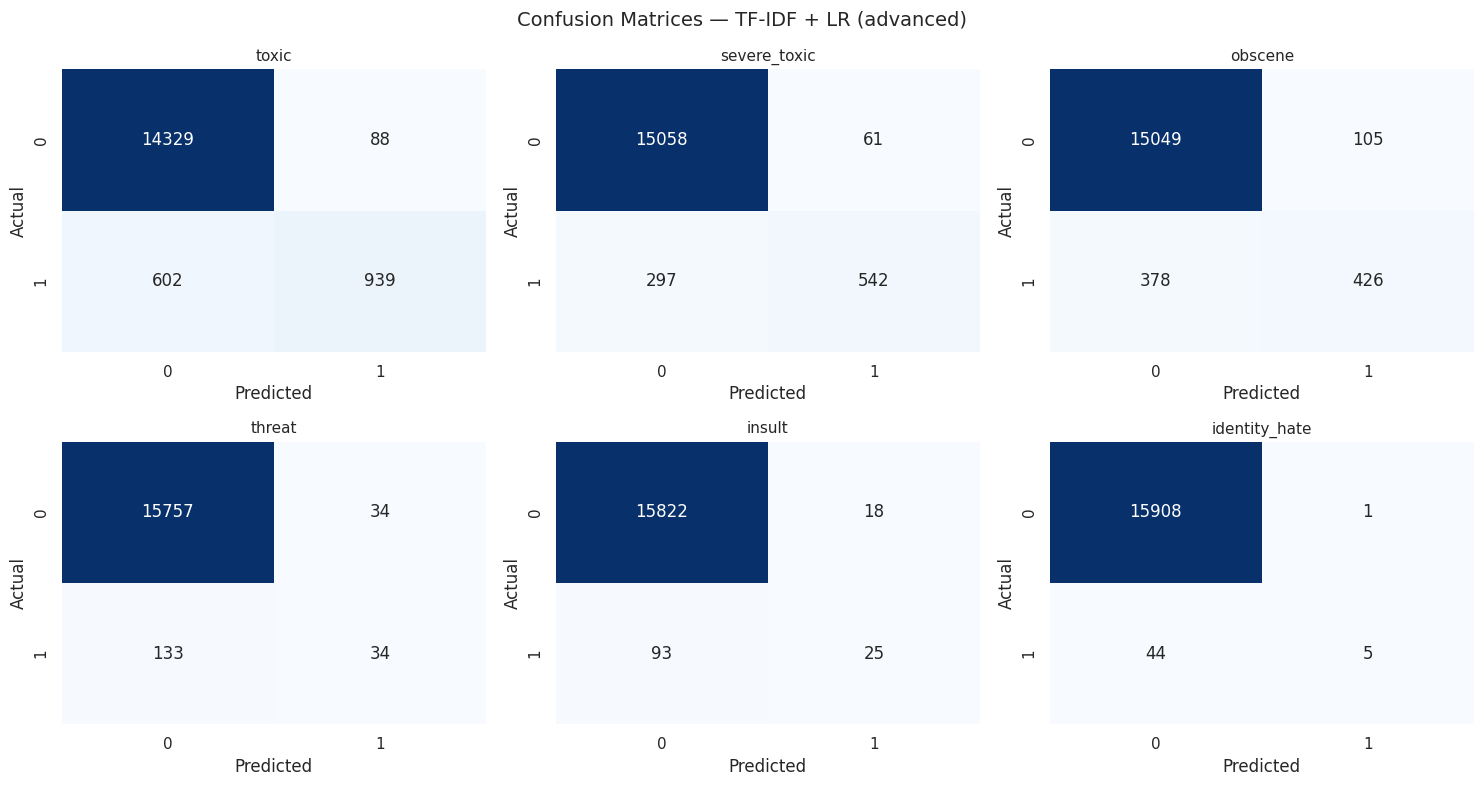

In [106]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

**The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.**

In [110]:
import joblib

joblib.dump(lr_raw, "lr_tfidf_model.pkl")
joblib.dump(lr_clean, "lr_tfidf_model.pkl")

['lr_tfidf_model.pkl']

In [113]:
joblib.dump(tfidf_clean, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [114]:
joblib.dump(tfidf_raw, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']